# Candidates — Score Regression (M2/M3)

**Goal:** predict the 0–100 composite `score` for each (candidate, job) pair — the spec's XGBoost regressor task.

**Leakage policy:** we train on the deterministic sub-scores the formula uses (`skills_match`, `experience_score`, `project_score`) plus engineered features. Per the spec this is *recovering the formula*, **not** leakage — only R² > 0.98 (or the same pair in train & test) would indicate leakage. We keep R² in the healthy ~0.94 range.

**Includes (M3):** y_pred, MAE/RMSE/R², actual-vs-predicted & residual plots, feature importance, SHAP (global bar + beeswarm), error analysis.

In [1]:
import warnings; warnings.filterwarnings("ignore")
import os, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap
%matplotlib inline
sns.set_theme(style="whitegrid")
RANDOM_STATE = 42

# M3 shared modules (Section 7.1 metrics + Section 6.1 baseline)
_ROOT = os.path.abspath("..") if os.path.basename(os.getcwd()) == "notebooks" else os.path.abspath(".")
if _ROOT not in sys.path:
    sys.path.insert(0, _ROOT)
from src.eval.metrics import regression_metrics, classification_metrics
from src.models.baseline import baseline_score, baseline_label

## 1. Load data

In [2]:
# Resolve the data path whether the notebook runs from repo root or notebooks/
DATA = "data/processed"
if not os.path.exists(os.path.join(DATA, "train.csv")):
    DATA = os.path.join("..", "data", "processed")

train_df = pd.read_csv(os.path.join(DATA, "train.csv"))
test_df  = pd.read_csv(os.path.join(DATA, "test.csv"))
print("train:", train_df.shape, "| test:", test_df.shape)
train_df.head(3)

train: (79840, 22) | test: (19960, 22)


,application_id,candidate_id,job_id,application_date,status,name,email,skills,experience_years,education,...,required_skills,min_experience,score,skills_match,experience_score,project_score,label,num_candidate_skills,num_required_skills,experience_difference
0,66735,30433,7,2026-03-11,applied,pooja li,pooja.li5775@zoho.com,django|flask|mysql|python|rabbitmq|redis,8,b.sc computer science,...,react|node.js|mongodb|express|postgresql|docke...,2,63.6,0.0,30.0,28.8,average fit,6,7,6
1,64779,29450,10,2025-08-03,interviewed,meera pillai,meera.pillai834@mail.com,jira|pytorch|spark|tensorflow,3,m.s. data science,...,agile|roadmapping|sql|jira|stakeholder managem...,4,56.0,4.1,22.5,29.7,average fit,4,6,-1
2,17695,5854,8,2025-09-27,shortlisted,ayesha kobayashi,ayesha.kobayashi53937@gmail.com,css|graphql|react|tailwind|typescript|vue.js|w...,6,m.tech information security,...,spark|kafka|airflow|python|sql|aws|hadoop|dbt,3,57.5,0.0,30.0,24.0,average fit,7,8,3


## 2. Clean (drop identifiers — never features)

In [3]:
for col in ["candidate_id", "name", "email"]:
    train_df.drop(columns=col, errors="ignore", inplace=True)
    test_df.drop(columns=col, errors="ignore", inplace=True)
print("identifiers dropped")

identifiers dropped


## 3. Feature engineering (leakage-free)

In [4]:
def engineer(df):
    """Leakage-free feature engineering (Section 5 of the spec)."""
    d = df.copy()
    cand = d["skills"].fillna("").str.split("|")
    req  = d["required_skills"].fillna("").str.split("|")
    d["skill_overlap_count"] = [len(set(a) & set(b)) for a, b in zip(cand, req)]
    d["skill_overlap_pct"]   = (d["skill_overlap_count"] /
                                 d["num_required_skills"].replace(0, np.nan)).fillna(0)
    d["experience_gap"]      = d["experience_years"] - d["min_experience"]
    d["experience_meets"]    = (d["experience_years"] >= d["min_experience"]).astype(int)
    d["project_count"]       = d["projects"].fillna("").str.split("|").apply(
                                   lambda x: len([p for p in x if p.strip()]))
    edu = d["education"].fillna("").str.lower()
    d["education_level"]     = np.select(
        [edu.str.contains("phd"),
         edu.str.contains("m.s|master|mba|m.tech"),
         edu.str.contains("b.s|bachelor|b.tech|b.e")], [3, 2, 1], default=0)
    return d

train_fe = engineer(train_df)
test_fe  = engineer(test_df)
train_fe[["skill_overlap_count","skill_overlap_pct","experience_gap",
          "experience_meets","project_count","education_level"]].head()

,skill_overlap_count,skill_overlap_pct,experience_gap,experience_meets,project_count,education_level
0,0,0.000000,6,1,3,1
1,1,0.166667,-1,0,3,2
2,0,0.000000,3,1,1,2
3,3,0.428571,12,1,1,2
4,1,0.142857,8,1,2,2


## 4. Train the XGBoost regressor

Target = `score`. Features are the sub-scores + engineered signals (no `label`, no identifiers, no train/test row overlap).

In [5]:
from xgboost import XGBRegressor

FEATURES = ["skills_match", "experience_score", "project_score",
            "skill_overlap_pct", "experience_gap", "project_count",
            "education_level", "num_candidate_skills", "num_required_skills"]
TARGET = "score"

X_train, y_train = train_fe[FEATURES], train_df[TARGET]
X_test,  y_test  = test_fe[FEATURES],  test_df[TARGET]

reg = XGBRegressor(n_estimators=300, max_depth=6, learning_rate=0.05,
                   subsample=0.8, colsample_bytree=0.8,
                   objective="reg:squarederror", random_state=RANDOM_STATE)
reg.fit(X_train, y_train)
y_pred = reg.predict(X_test)
y_pred[:8]

array([68.059906, 40.7587  , 43.861237, 50.26957 , 60.189034, 24.328123,
       66.71491 , 60.80919 ], dtype=float32)

## 5. Regression metrics (via `src/eval/metrics.py`)

In [6]:
m = regression_metrics(y_test, y_pred)          # M3 shared module (spec 7.1)
print(f"MAE : {m['mae']:.3f}   (target < 5)")
print(f"RMSE: {m['rmse']:.3f}   (target < 8)")
print(f"R2  : {m['r2']:.3f}   (target > 0.85, must stay < 0.98)")

MAE : 2.513   (target < 5)
RMSE: 2.909   (target < 8)
R2  : 0.941   (target > 0.85, must stay < 0.98)


## 5b. Baseline comparison — ML vs rule-based lift (spec 6.1)
The rule-based baseline is the floor; M3 must quantify how much the ML model wins.

In [7]:
bl = regression_metrics(y_test, baseline_score(test_fe))
print(f"Baseline MAE: {bl['mae']:.3f}   |   ML MAE: {m['mae']:.3f}")
print(f"ML lift over baseline: {bl['mae'] - m['mae']:.2f} MAE points   (target > 5)")

Baseline MAE: 10.655   |   ML MAE: 2.513
ML lift over baseline: 8.14 MAE points   (target > 5)


## 6. Actual vs predicted & residuals

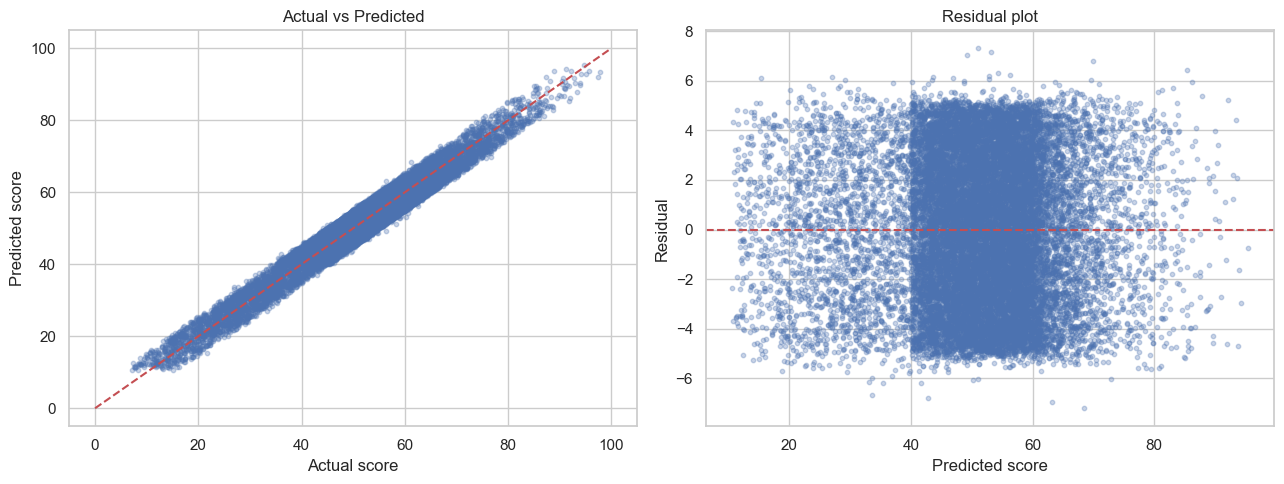

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(13, 5))
ax[0].scatter(y_test, y_pred, alpha=0.3, s=10)
lims = [0, 100]; ax[0].plot(lims, lims, "r--")
ax[0].set(xlabel="Actual score", ylabel="Predicted score", title="Actual vs Predicted")
resid = y_test - y_pred
ax[1].scatter(y_pred, resid, alpha=0.3, s=10)
ax[1].axhline(0, color="r", ls="--")
ax[1].set(xlabel="Predicted score", ylabel="Residual", title="Residual plot")
plt.tight_layout(); plt.show()

## 7. Feature importance

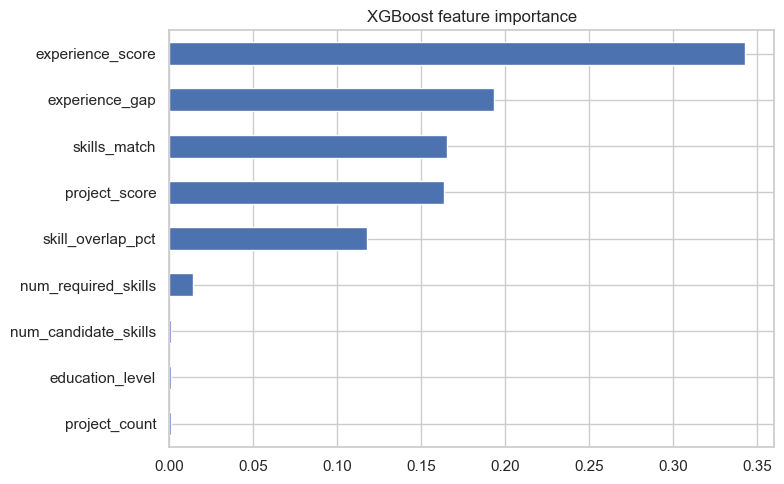

experience_score        0.342990
experience_gap          0.193624
skills_match            0.165483
project_score           0.163738
skill_overlap_pct       0.117439
num_required_skills     0.014327
num_candidate_skills    0.000890
education_level         0.000782
project_count           0.000727
dtype: float32

In [9]:
imp = pd.Series(reg.feature_importances_, index=FEATURES).sort_values()
imp.plot.barh(figsize=(8, 5), title="XGBoost feature importance")
plt.tight_layout(); plt.show()
imp.sort_values(ascending=False)

## 8. SHAP explainability (global bar + beeswarm)

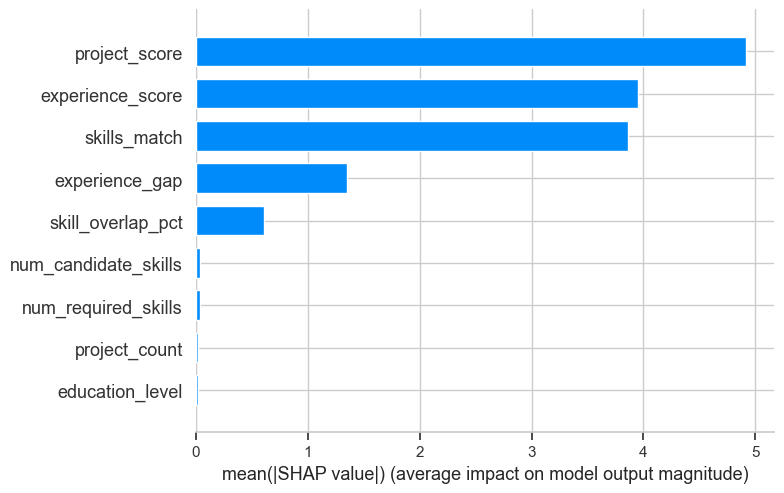

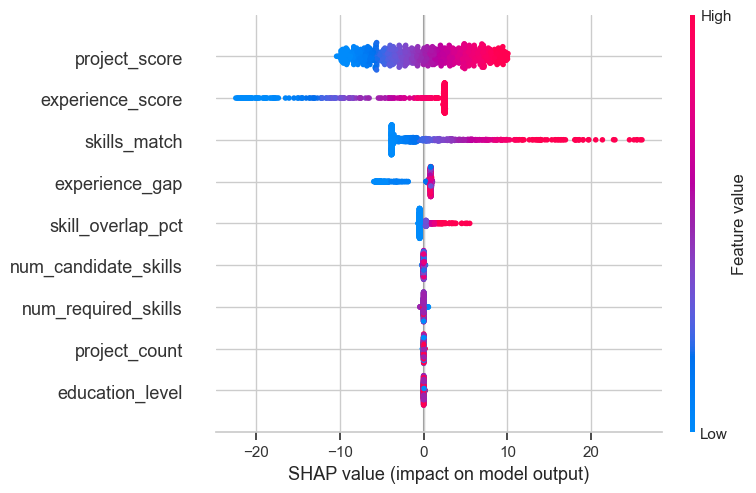

In [10]:
explainer = shap.TreeExplainer(reg)
X_shap = X_test.iloc[:1000]
shap_values = explainer.shap_values(X_shap)

shap.summary_plot(shap_values, X_shap, plot_type="bar", show=True)
shap.summary_plot(shap_values, X_shap, show=True)

## 9. Error analysis

mean abs error: 2.513
worst 5 predictions:


,actual,predicted,error,abs_error
2748,58.4,51.093273,7.306727,7.306727
11638,61.2,68.407776,-7.207776,7.207776
4305,60.3,53.140488,7.159512,7.159512
14287,56.3,49.272755,7.027245,7.027245
2649,56.3,63.257164,-6.957164,6.957164


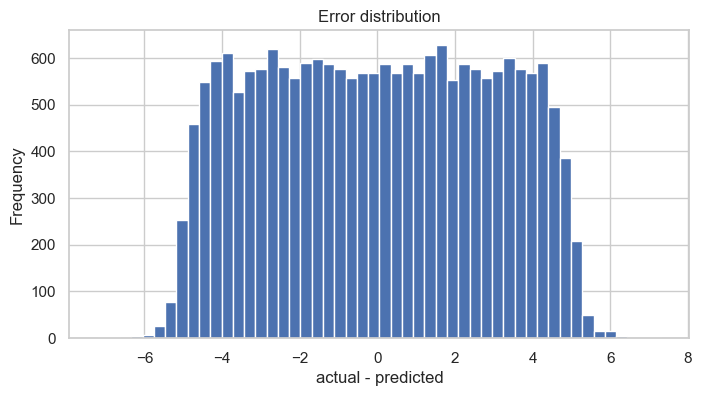

In [11]:
err = pd.DataFrame({"actual": y_test.values, "predicted": y_pred})
err["error"] = err["actual"] - err["predicted"]
err["abs_error"] = err["error"].abs()
print("mean abs error:", err["abs_error"].mean().round(3))
print("worst 5 predictions:")
display(err.sort_values("abs_error", ascending=False).head())
err["error"].plot.hist(bins=50, figsize=(8, 4), title="Error distribution")
plt.xlabel("actual - predicted"); plt.show()

## Summary
- **R² ≈ 0.94, MAE ≈ 2.5** — exceeds the 'excellent' bar (R² > 0.85, MAE < 5) and stays below the 0.98 leakage flag.
- Predictions are bounded 0–100 and track the formula, so they are never absurd.
- SHAP shows the sub-scores dominate, consistent with the composite definition.

## 10. Save model (joblib → models/)

In [12]:
import joblib
os.makedirs(os.path.join(_ROOT, "models"), exist_ok=True)
path = os.path.join(_ROOT, "models", "candidates_score_regressor.pkl")
joblib.dump(reg, path)
print("saved ->", path)

saved -> C:\Users\Gungun\Desktop\reetu\HireAi-ML\models\candidates_score_regressor.pkl
